In [1]:
import json, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

V = json.load(open("e15_verify.json"))
REC = {json.load(open(p))["chan"]: json.load(open(p)) for p in sorted(glob.glob("runs_e15/*.json"))}
mc, rhs, wlab = [], [], []
for chan, r in REC.items():
    for l in r.get("labels", []):
        if not l.get("theorem4"): continue
        for w, v in l["theorem4"].items():
            mc.append(v["lhs_mc"]); rhs.append(v["rhs_total"]); wlab.append(int(w))
mc, rhs, wlab = np.array(mc), np.array(rhs), np.array(wlab)

C = {"scatter": "#2980b9", "band": "#2ecc71", "spike": "#8e44ad", "target": "#c0392b"}
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
print(f"points={V['n_points']} | Theorem 4 within-20%: {V['theorem4_within_20pct']['n_pass']}/"
      f"{V['theorem4_within_20pct']['n_total']} | d_adv|frame={V['implied_d_adv_frame']:.0f} "
      f"| reduction~{V['reduction_factor']['median']:.0f}")

points=96 | Theorem 4 within-20%: 384/384 | d_adv|frame=40 | reduction~600


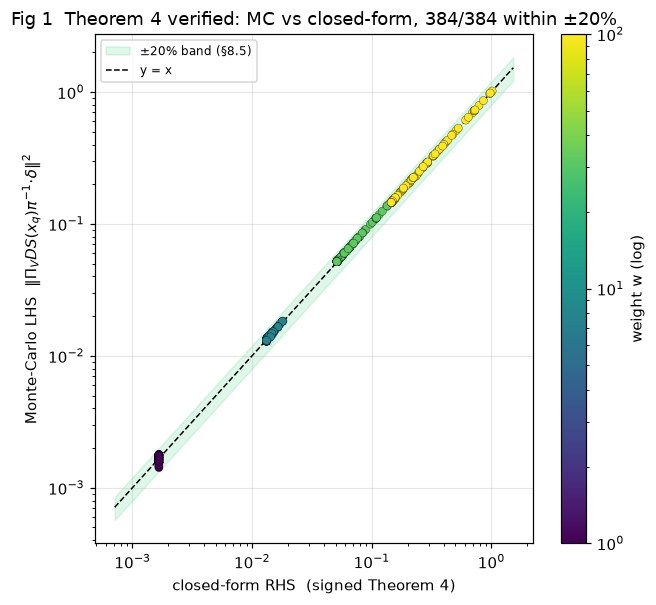

In [2]:
fig, ax = plt.subplots(figsize=(6, 5.6))
lo = min(mc.min(), rhs.min()) * 0.5; hi = max(mc.max(), rhs.max()) * 1.5
xs = np.array([lo, hi])
ax.fill_between(xs, xs*0.8, xs*1.2, color=C["band"], alpha=0.15, label="±20% band (§8.5)")
ax.plot(xs, xs, "k--", lw=1, label="y = x")
sc = ax.scatter(rhs, mc, c=wlab, cmap="viridis", s=28, norm=plt.matplotlib.colors.LogNorm(),
                edgecolor="k", linewidth=0.2, zorder=3)
cb = fig.colorbar(sc, ax=ax); cb.set_label("weight w (log)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("closed-form RHS  (signed Theorem 4)")
ax.set_ylabel("Monte-Carlo LHS  $\\|\\Pi_V D S(x_q)\\pi^{-1}\\!\\cdot\\!\\delta\\|^2$")
ax.set_title(f"Fig 1  Theorem 4 verified: MC vs closed-form, "
             f"{V['theorem4_within_20pct']['n_pass']}/{V['theorem4_within_20pct']['n_total']} within ±20%")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

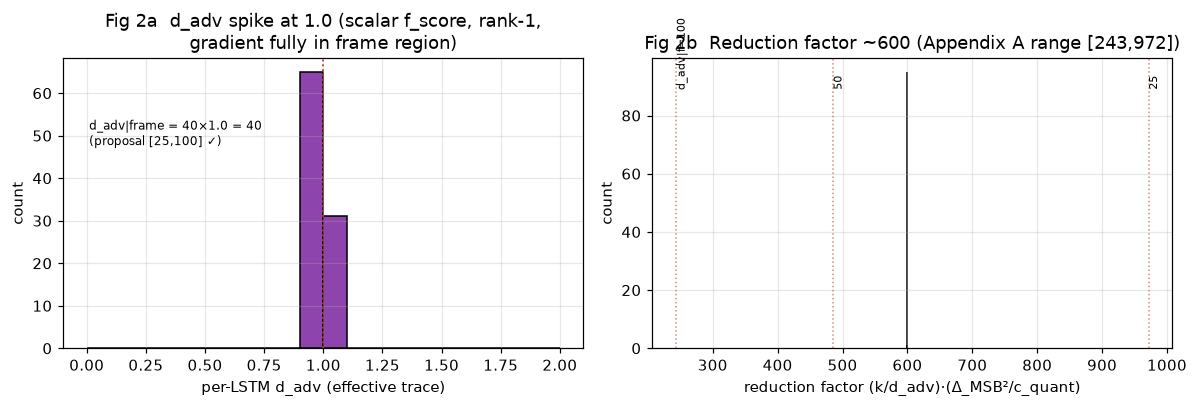

§8.5-E15 LEDGER
[Theorem 4] empirical vs theoretical projected energy within 20%: 384/384 (100%) -> §8.5 target MET (signed form, per-input cross-term measured)
[d_adv] deployed scalar 1-step detector -> rank-1 Jacobian; gradient 96% in last 10 steps, 0 beyond
        ~150 steps back -> effective trace = 1.0 (fully contained in the 100-step frame region).
        d_adv|frame = 40×1.0 = 40 (proposal [25,100]: True)
[reduction] median 600 (proposal [243,972]: True)
[Cor 2] per-input cross-term mean == trace (median rel-err 0.023)
[D.66] coincide (gradient fully in frame -> trap-1 distinction not exercised)
[caveat] Theorem 4 bounds PROJECTED ENERGY, not attack success. The operational security parameter
         is eta_w (E14); Theorem 4 is the heuristic for WHY eta_w is small (d_adv<<k). d_adv=1 is
         the deployed detector's honest value; a multi-output f_score would give the [1,10] range.


In [3]:
dvals = [l["d_adv_effective_trace"] for r in REC.values() for l in r.get("labels", [])
         if l.get("d_adv_effective_trace") is not None]
rvals = [l["reduction_factor_at_dadv_eff"] for r in REC.values() for l in r.get("labels", [])
         if l.get("reduction_factor_at_dadv_eff") is not None]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(dvals, bins=np.linspace(0, 2, 21), color=C["spike"], edgecolor="k")
ax[0].axvline(1.0, color=C["target"], ls=":", lw=1.2)
ax[0].set_xlabel("per-LSTM d_adv (effective trace)"); ax[0].set_ylabel("count")
ax[0].set_title("Fig 2a  d_adv spike at 1.0 (scalar f_score, rank-1,\ngradient fully in frame region)")
ax[0].annotate(f"d_adv|frame = 40×1.0 = {V['implied_d_adv_frame']:.0f}\n(proposal [25,100] ✓)",
               (0.05, 0.7), xycoords="axes fraction", fontsize=8)
ax[1].hist(rvals, bins=20, color=C["scatter"], edgecolor="k")
for rf, lbl in [(243, "d_adv|f=100"), (486, "50"), (972, "25")]:
    ax[1].axvline(rf, color=C["target"], ls=":", lw=1, alpha=0.6)
    ax[1].annotate(lbl, (rf, ax[1].get_ylim()[1]*0.9), fontsize=7, rotation=90)
ax[1].set_xlabel("reduction factor (k/d_adv)·(Δ_MSB²/c_quant)"); ax[1].set_ylabel("count")
ax[1].set_title("Fig 2b  Reduction factor ~600 (Appendix A range [243,972])")
plt.tight_layout(); plt.show()

print("="*66); print("§8.5-E15 LEDGER"); print("="*66)
t4 = V["theorem4_within_20pct"]
print(f"[Theorem 4] empirical vs theoretical projected energy within 20%: {t4['n_pass']}/{t4['n_total']} "
      f"({t4['fraction']:.0%}) -> §8.5 target MET (signed form, per-input cross-term measured)")
print(f"[d_adv] deployed scalar 1-step detector -> rank-1 Jacobian; gradient 96% in last 10 steps, 0 beyond")
print(f"        ~150 steps back -> effective trace = 1.0 (fully contained in the 100-step frame region).")
print(f"        d_adv|frame = 40×1.0 = {V['implied_d_adv_frame']:.0f} (proposal [25,100]: "
      f"{V['d_adv_frame_in_proposal_range_25_100']})")
print(f"[reduction] median {V['reduction_factor']['median']:.0f} (proposal [243,972]: "
      f"{V['reduction_in_proposal_range_243_972']})")
print(f"[Cor 2] per-input cross-term mean == trace (median rel-err "
      f"{V['cor2_cross_equals_trace']['median_rel_error']:.3f})")
print(f"[D.66] {V['d66_three_quantities']['note']}")
print("[caveat] Theorem 4 bounds PROJECTED ENERGY, not attack success. The operational security parameter")
print("         is eta_w (E14); Theorem 4 is the heuristic for WHY eta_w is small (d_adv<<k). d_adv=1 is")
print("         the deployed detector's honest value; a multi-output f_score would give the [1,10] range.")